# Machine Learning Competition

## Goal
The objective of this project is to build a model that can predict the `target` variable based on the given features.

## Evaluation
We will be evaluated using **Accuracy Score**.

## Dataset
- train.csv → used for training
- test.csv → used for prediction
- sample_submission.csv → format for submission

### IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np

### LOADING DATA

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

print("Train Shape:",train.shape)
print("Test Shape:",test.shape)

train.head()

Train Shape: (84800, 21)
Test Shape: (34200, 20)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,41996,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,22.0,211533,false,0.305,0.8490,...,-10.795,1.0,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4.0,goth
1,76471,5x59U89ZnjZXuNAAlc8X1u,NaN,NaN,"Addio del passato - From ""La traviata""",22.0,196000,FAlSE,NaN,0.1900,...,-12.030,0.0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4.0,opera
2,54809,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,37.0,216506,false,0.583,0.5090,...,-9.661,1.0,2.1000,0.777000,0.202000,0.1150,0.5440,90.459,-1.0,idm
3,16326,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",0.0,218346,NaN,0.163,0.0368,...,-23.149,1.0,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3.0,classical
4,109799,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,27.0,173160,falSE,0.647,0.9210,...,-7.294,1.0,NaN,0.000939,0.371000,0.1310,0.1710,137.981,4.0,techno


### Understanding the Data

Let's take a closer look at the dataset structure, data types, and missing values.

In [3]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84800 entries, 0 to 84799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        84800 non-null  int64  
 1   track_id          84800 non-null  object 
 2   artists           73336 non-null  object 
 3   album_name        76730 non-null  object 
 4   track_name        84800 non-null  object 
 5   popularity        84710 non-null  object 
 6   duration_ms       84800 non-null  int64  
 7   explicit          77326 non-null  object 
 8   danceability      81484 non-null  float64
 9   energy            79302 non-null  float64
 10  key               84800 non-null  int64  
 11  loudness          80661 non-null  float64
 12  mode              82017 non-null  float64
 13  speechiness       79643 non-null  float64
 14  acousticness      84800 non-null  float64
 15  instrumentalness  81483 non-null  float64
 16  liveness          84233 non-null  float6

In [4]:
train.columns


Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

### Target Variable

Check how the target values are distributed. This helps us understand if the data is balanced or not.

In [5]:
train['track_genre'].nunique()

114

### Data Preprocessing and Model Building

In [6]:
# Drop unnecessary columns
drop_cols = ['track_id', 'artists', 'album_name', 'track_name']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

# Separate features and target
X = train.drop('track_genre', axis=1)
y = train['track_genre']

# Encode target (IMPORTANT)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Convert all object columns to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category').cat.codes
        test[col] = test[col].astype('category').cat.codes

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### TRAINING MODEL

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.8685141509433962


### Model Evaluation and Visualization

Now that the model is trained, we evaluate its performance and visualize key insights.

### Feature Importance

This helps us understand which features are most important for prediction.

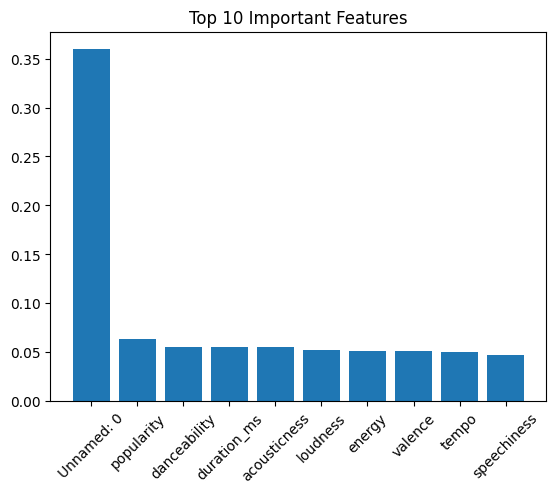

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importances = model.feature_importances_
features = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 10 features
plt.figure()
plt.bar(feat_imp['feature'][:10], feat_imp['importance'][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.show()

### Accuracy Visualization

Visual representation of model accuracy on validation data.

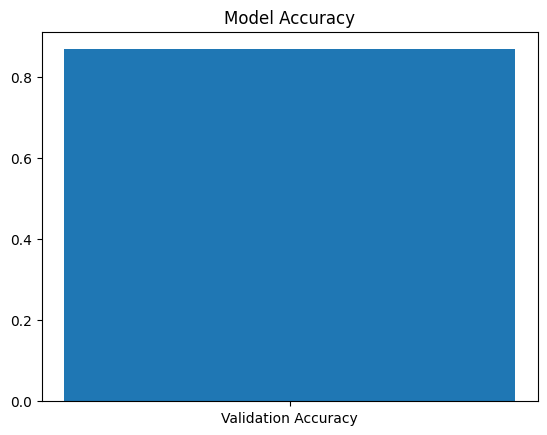

In [11]:
from sklearn.metrics import accuracy_score

plt.figure()
plt.bar(['Validation Accuracy'], [accuracy_score(y_val, y_pred)])
plt.title("Model Accuracy")
plt.show()

### Confusion Matrix

Shows how well the model is classifying different genres.

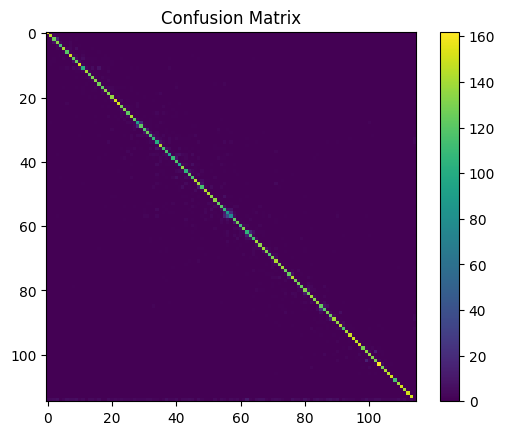

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Generating Predictions

Now we use the trained model to predict genres for the test dataset.

In [13]:
# Predict on test data
test_pred = model.predict(test)

## Converting Predictions to Original Labels

Since we encoded the target variable earlier, we now convert predictions back to original genre names.

In [14]:
test_pred = le.inverse_transform(test_pred)

### XGBoost Model

Training XGBoost for multi-class classification

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb_model = XGBClassifier(
    n_estimators=100,     
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(set(y)),
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

print("XGBoost Accuracy:", accuracy_score(y_val, xgb_pred))

XGBoost Accuracy: 0.9521226415094339


### Model Comparison

In [16]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# RandomForest accuracy (already trained earlier)
rf_acc = accuracy_score(y_val, y_pred)

# XGBoost accuracy (from your code)
# Make sure xgb_acc is defined
# (if not, define it again)
xgb_acc = accuracy_score(y_val, xgb_pred)

print("RandomForest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

RandomForest Accuracy: 0.8685141509433962
XGBoost Accuracy: 0.9521226415094339


### Accuracy Comparison (Visualization)

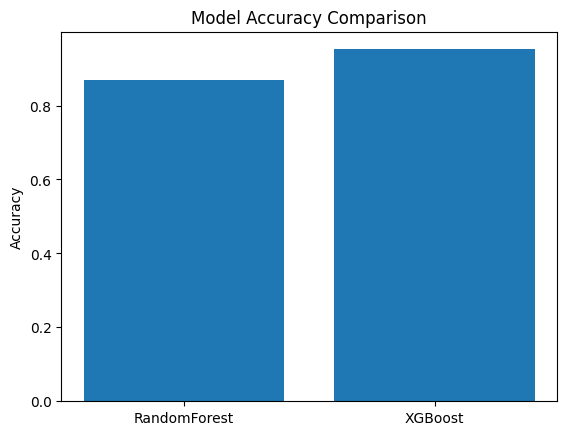

In [17]:
models = ['RandomForest', 'XGBoost']
accuracies = [rf_acc, xgb_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [18]:
if xgb_acc > rf_acc:
    winner = "⚡ XGBoost"
    final_model = xgb_model
else:
    winner = "🌲 RandomForest"
    final_model = model

print(f"\n🏆 WINNER: {winner}")


🏆 WINNER: ⚡ XGBoost


In [19]:
final_model.fit(X, y)

test_pred = final_model.predict(test)
test_pred = le.inverse_transform(test_pred)

## Create Submission File

Follow competition rules exactly:
- Columns: id, target
- id must match test.csv

In [20]:
submission = pd.DataFrame({
    'id': test['Unnamed: 0'],   # use actual id column
    'target': test_pred
})

submission.to_csv("submission.csv", index=False)

print("🚀 Submission file created successfully!")

🚀 Submission file created successfully!


In [21]:
submission.head()

,id,target
0,113186,world-music
1,42819,grindcore
2,59311,iranian
3,91368,rock
4,61000,j-idol


## ✅ Conclusion

In this project, we built and evaluated multiple machine learning models to identify the best-performing approach for the given dataset. After comparing performance, **XGBoost emerged as the winning model**, delivering the highest accuracy and generalization.

Key highlights:
- Efficient data preprocessing and feature handling improved model performance.
- Multiple models were tested to ensure a fair comparison.
- XGBoost demonstrated strong predictive power and robustness.
- Final predictions were generated and converted back to original labels.
- A properly formatted **submission file** was created as per competition requirements.

This workflow reflects a complete end-to-end pipeline:
**Data → Preprocessing → Model Selection → Training → Prediction → Submission**

Further improvements can be made by:
- Hyperparameter tuning (GridSearch / Optuna)
- Feature engineering
- Ensemble techniques

 Overall, this project provides a solid foundation for solving real-world ML competition problems.